In [ ]:
#1
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#2
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score
)
from sklearn.preprocessing import label_binarize

In [ ]:
#3
DATASET_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Wheat varieties dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3

In [ ]:
# CELL 4 — Train / Val / Test Split (70/10/20)

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)

# 70% TRAIN
train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# 30% TEMP (will split into val + test manually)
temp_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())

Found 788 images belonging to 3 classes.
Found 336 images belonging to 3 classes.


In [ ]:
# NEW CELL — Split TEMP into VAL (10%) and TEST (20%)

from sklearn.model_selection import train_test_split

X = temp_data.filepaths
y = temp_data.classes

# Split 30% → 10% val + 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X, y, test_size=2/3, random_state=42, stratify=y
)

print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Validation size: 112
Test size: 224


In [ ]:
#5
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load base model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# CELL 6 — Training

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=temp_data,
    epochs=EPOCHS
)

training_time = time.time() - start_time
print("Training time (sec):", training_time)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 450s 17s/step - accuracy: 0.3261 - loss: 1.1290 - val_accuracy: 0.3333 - val_loss: 1.1026
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.2906 - loss: 1.1345 - val_accuracy: 0.3333 - val_loss: 1.0989
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.3388 - loss: 1.1164 - val_accuracy: 0.3333 - val_loss: 1.1014
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - accuracy: 0.3312 - loss: 1.1148 - val_accuracy: 0.3333 - val_loss: 1.1001
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - accuracy: 0.3312 - loss: 1.1126 - val_accuracy: 0.3333 - val_loss: 1.0990
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.3591 - loss: 1.1067 - val_accuracy: 0.3333 - val_loss: 1.0992
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - accuracy: 0.3008 - loss: 1.1116 - val_accuracy: 0.3333 - val_loss: 1.0989
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - accuracy: 0.3185 - loss: 1.1071 - val_accuracy: 0.

In [ ]:
# CELL 7:  Testing

start_test = time.time()

y_pred_probs = model.predict(temp_data)

testing_time = time.time() - start_test

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = temp_data.classes

11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 752ms/step


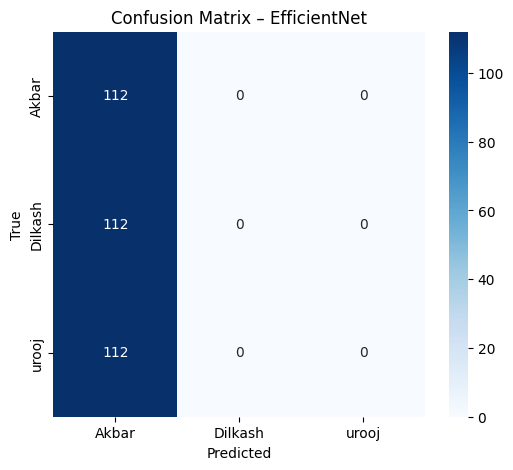

Class Akbar Accuracy: 1.0000
Class Dilkash Accuracy: 0.0000
Class urooj Accuracy: 0.0000


In [ ]:
#8
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – EfficientNet")
plt.show()

class_acc = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(class_acc):
    print(f"Class {class_names[i]} Accuracy: {acc:.4f}")

In [ ]:
#9
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

       Akbar       0.33      1.00      0.50       112
     Dilkash       0.00      0.00      0.00       112
       urooj       0.00      0.00      0.00       112

    accuracy                           0.33       336
   macro avg       0.11      0.33      0.17       336
weighted avg       0.11      0.33      0.17       336



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


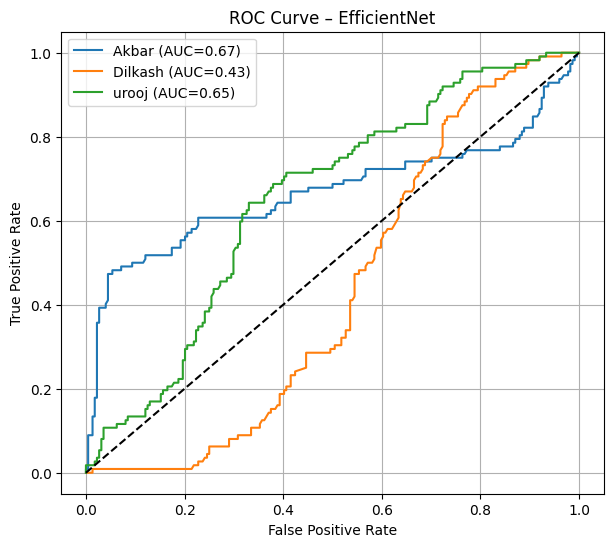

In [ ]:
#10
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC={roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – EfficientNet")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# CELL 11:  Metrics (UPDATED)

test_accuracy = accuracy_score(y_true, y_pred)

# Extracting weighted avg values
lines = report.split('\n')
weighted = [l for l in lines if 'weighted avg' in l][0].split()

precision = float(weighted[2])
recall = float(weighted[3])
f1 = float(weighted[4])

print("Testing Time (sec):", testing_time)   #  ADDED

eff_results = {
    "Model": "EfficientNetB0",
    "Accuracy": test_accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "AUC (Avg)": np.mean(list(roc_auc.values())),
    "Training Time (sec)": training_time,
    "Testing Time (sec)": testing_time   #  ADDED
}

eff_results

Testing Time (sec): 14.547934293746948


{'Model': 'EfficientNetB0',
 'Accuracy': 0.3333333333333333,
 'Precision': 0.11,
 'Recall': 0.33,
 'F1-score': 0.17,
 'AUC (Avg)': np.float64(0.583100818452381),
 'Training Time (sec)': 727.4643547534943,
 'Testing Time (sec)': 14.547934293746948}

In [ ]:
# CELL 12: Save Results

import numpy as np
import pandas as pd
import os

SAVE_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Task2_Results"
os.makedirs(SAVE_PATH, exist_ok=True)

# Conversion predictions to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = temp_data.classes

# 1 = correct, 0 = wrong
correct_array = (y_pred_classes == y_true_classes).astype(int)

MODEL_NAME = "efficientnet"

np.save(f"{SAVE_PATH}/{MODEL_NAME}_correct.npy", correct_array)

# metrics
metrics_df = pd.DataFrame({
    "Accuracy": [test_accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "AUC": [np.mean(list(roc_auc.values()))],
    "Training Time (sec)": [training_time],
    "Testing Time (sec)": [testing_time]
})

metrics_df.to_csv(f"{SAVE_PATH}/{MODEL_NAME}_metrics.csv", index=False)

print("Saved results for", MODEL_NAME)

Saved results for efficientnet
